In [ ]:
import torch
import numpy as np
from torch import nn
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, Dataset, Subset
import os
import random
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch import optim

In [ ]:
!cp -r drive/MyDrive/PlantVillage /content/
path="/content/PlantVillage"

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

Number of total classes: 15
Pepper__bell___Bacterial_spot
256
256


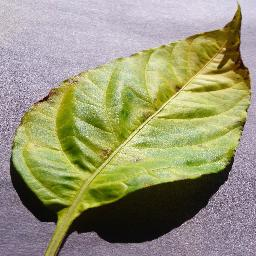

In [ ]:
path = "/content/drive/MyDrive/PlantVillage"

classes = [name for name in os.listdir(path) if os.path.isdir(os.path.join(path, name))]

class_name = random.choice(classes)
class_path = os.path.join(path, class_name)
img_name = random.choice(os.listdir(class_path))
img_path = os.path.join(class_path, img_name)

img = Image.open(img_path)

print(f"Number of total classes: {len(classes)}")
print(class_name)
print(img.height)
print(img.width)

img


In [ ]:
data_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.ToTensor()
])

In [ ]:
def visualize_transform(img_path, transform):
    img = Image.open(img_path)
    print(img)
    transformed_img = transform(img)
    print(transformed_img)
    # if isinstance(transformed_img, torch.Tensor):
    #     transformed_img = transforms.ToPILImage()(transformed_img)

    # fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    # axes[0].imshow(img)
    # axes[0].set_title("Original")
    # axes[0].axis("off")

    # axes[1].imshow(transformed_img)
    # axes[1].set_title("Transformed")
    # axes[1].axis("off")

    # plt.show()

In [ ]:
class_name = random.choice(classes)
class_path = os.path.join(path, class_name)
img_name = random.choice(os.listdir(class_path))
img_path = os.path.join(class_path, img_name)

visualize_transform(img_path, data_transform)

<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=256x256 at 0x78BAEFF120C0>
tensor([[[0.8196, 0.8157, 0.8275,  ..., 0.7804, 0.7804, 0.7882],
         [0.8196, 0.8118, 0.8235,  ..., 0.7647, 0.7490, 0.7490],
         [0.8196, 0.8118, 0.8196,  ..., 0.7882, 0.7765, 0.7725],
         ...,
         [0.6196, 0.6392, 0.6745,  ..., 0.5373, 0.5373, 0.5137],
         [0.6235, 0.6431, 0.6196,  ..., 0.5569, 0.5490, 0.4980],
         [0.6157, 0.6549, 0.6627,  ..., 0.5647, 0.5686, 0.5176]],

        [[0.8039, 0.8000, 0.8118,  ..., 0.7647, 0.7647, 0.7725],
         [0.8039, 0.7961, 0.8078,  ..., 0.7490, 0.7333, 0.7333],
         [0.8039, 0.7961, 0.8039,  ..., 0.7725, 0.7608, 0.7569],
         ...,
         [0.5765, 0.5961, 0.6314,  ..., 0.4863, 0.4863, 0.4627],
         [0.5804, 0.6000, 0.5765,  ..., 0.5059, 0.4980, 0.4471],
         [0.5725, 0.6118, 0.6196,  ..., 0.5137, 0.5176, 0.4667]],

        [[0.8078, 0.8039, 0.8157,  ..., 0.7686, 0.7686, 0.7765],
         [0.8078, 0.8000, 0.8118,  ..., 0

In [ ]:
full_dataset = datasets.ImageFolder(root=path, transform=None)
full_dataset

class_to_idx = full_dataset.class_to_idx
idx_to_class = {value: key for key, value in class_to_idx.items()}
classes = list(class_to_idx.keys())

In [ ]:
targets = [sample[1] for sample in full_dataset.samples]

train_idx, test_idx = train_test_split(
    np.arange(len(targets)),
    test_size=0.2,
    random_state=42,
    stratify=targets
)

In [ ]:
print(f"Number of Train images: {len(train_idx)} | Number of Test images: {len(test_idx)}")

Number of Train images: 16510 | Number of Test images: 4128


In [ ]:
temp_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

temp_full = datasets.ImageFolder(root=path, transform=temp_transform)
temp_train = Subset(temp_full, train_idx)

In [ ]:
def get_mean_std(dataset, batch_size=16, num_workers=2):
  loader = DataLoader(dataset, batch_size=batch_size, num_workers=num_workers, shuffle=False)
  rgb_sum = torch.zeros(3)
  rgb_sumsq = torch.zeros(3)
  count_pixels = 0

  for x, _ in loader:
    b, c, h, w = x.shape
    count_pixels += b * h * w
    rgb_sum += x.sum(dim=[0, 2, 3])
    rgb_sumsq += (x**2).sum(dim=[0, 2, 3])

  mean = rgb_sum / count_pixels
  std = torch.sqrt(rgb_sumsq / count_pixels - mean **2)
  return mean, std

In [ ]:
#mean_tensor, std_tensor = get_mean_std(temp_train)
#mean = mean_tensor.tolist()
#std = std_tensor.tolist()

In [ ]:
#mean

In [ ]:
#std


In [ ]:
mean = [0.45924949645996094, 0.47546207904815674, 0.4114915728569031]
std = [0.18597887456417084, 0.16258414089679718, 0.20079754292964935]

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

In [ ]:
train_data_all = datasets.ImageFolder(root=path, transform=train_transform)
test_data_all = datasets.ImageFolder(root=path, transform=test_transform)

train_set = Subset(train_data_all,train_idx)
test_set = Subset(test_data_all,test_idx)

In [ ]:
len(train_set), len( test_set)

(16510, 4128)

In [ ]:
class SampleCNN(nn.Module):
    def __init__(self, input_shape, output_shape, hidden_units):
        super().__init__()
        self.layer = nn.Sequential(
            nn.Flatten(),  # Flatten the input (batch_size, 3, 224, 224) -> (batch_size, 3*224*224)
            nn.Linear(in_features=input_shape, out_features=hidden_units),  # First fully connected layer
            nn.ReLU(),  # Add non-linearity
            nn.Linear(in_features=hidden_units, out_features=output_shape)  # Output layer
        )

    def forward(self, x):
        return self.layer(x)

In [ ]:
input_shape = 3 * 224 * 224   # Image shape: (3 channels, 224x224 pixels)
output_shape = 15             # Number of classes
hidden_units = 256            # Hidden layer size

# Create model instance
sampleCnn = SampleCNN(input_shape, output_shape, hidden_units)
print(sampleCnn)

SampleCNN(
  (layer): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=150528, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=15, bias=True)
  )
)


In [ ]:
class newCNN(nn.Module):
  def __init__(self, num_classes=15):
    super().__init__()

    self.block1 = nn.Sequential(
        nn.Conv2d(in_channels=3,out_channels=32, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=32,out_channels=32, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2, 2)
    )

    self.block2 = nn.Sequential(
        nn.Conv2d(in_channels=32,out_channels=64, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=64,out_channels=64, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)

    )

    self.block3 = nn.Sequential(
        nn.Conv2d(in_channels=64,out_channels=128, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=128,out_channels=128, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)

    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=128*28*28, out_features=512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(in_features=512, out_features=num_classes),


    )

  def forward(self, x):

    x = self.block1(x)

    x = self.block2(x)

    x = self.block3(x)

    x = self.classifier(x)
    return x

'class newCNN(nn.Module):\n  DEF __init__(self):\n    super.__init__()\n\n    Self.block1 = nn.Sequential(\n        nn.Conv2d(in_channels=3,out_channels=32, kernel_size=3, padding=1),\n        nn.ReLU(),\n        nn.Conv2d(in_channels=32,out_channels=32, kernel_size=3, padding=1),\n        nn.ReLU(),\n        nn.MaxPool2d(2, 2)\n    )\n\n    self.block2 = nn.Sequential(\n        nn.Conv2d(in_channels=32,out_channels=64, kernel_size=3, padding=1),\n        nn.ReLU(),\n        nn.Conv2d(in_channels=64,out_channels=64, kernel_size=3, padding=1),\n        nn.ReLU(),\n        nn.MaxPool2d(kernel_size=2, stride=2)\n\n    )\n\n    self.block3 = nn.Sequential(\n        nn.Conv2d(in_channels=64,out_channels=128, kernel_size=3, padding=1),\n        nn.ReLU(),\n        nn.Conv2d(in_channels=128,out_channels=128, kernel_size=3, padding=1),\n        nn.ReLU(),\n        nn.MaxPool2d(kernel_size=2, stride=2)\n\n    )\n\n    self.classifier = nn.Sequential(\n        nn.Flatten(),\n        nn.Linear(in

In [ ]:
# Create DataLoaders
train_loader = DataLoader(train_set, batch_size=32, shuffle=True, num_workers=0)
test_loader = DataLoader(test_set, batch_size=32, shuffle=False, num_workers=0)

# Create an instance of newCNN
num_classes = len(classes)  # Define num_classes based on the loaded data
model = newCNN(num_classes=num_classes).to(device)
print(model)


# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
epochs = 2
for epoch in range(epochs):
    model.train() # Set model to training mode
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device) # Move data to device

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(train_set)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}")

# Evaluation loop (optional)
model.eval() # Set model to evaluation mode
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device) # Move data to device
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the model on the {total} test images: {100 * correct / total}%')

Epoch 1/2, Loss: 3.3032
Epoch 2/2, Loss: 2.2122
